# Online Retail — Customer Segmentation

**Goal:** segment customers of a UK-based online retailer into actionable groups using unsupervised learning (K-Means).

**Approach:**
1. **Load & explore** the raw transaction data (structure, quality, coverage).
2. **Clean & scope** — drop unidentified customers, returns/cancellations and non-product line items, and restrict to the UK (which is ~89% of activity).
3. **Engineer customer-level features** in the RFM spirit (recency, frequency, monetary + tenure).
4. **Preprocess** — log-transform skewed features, then standardize.
5. **Cluster** with K-Means, choosing *k* via the elbow plus three internal validation metrics.
6. **Profile & visualize** the resulting segments.

In [1]:
import polars as pl                       # fast DataFrame library used for all the data wrangling
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,        # mean separation/cohesion across all points (higher = better)
    silhouette_samples,      # per-point silhouette, for the per-cluster silhouette plot
    davies_bouldin_score,    # average cluster overlap (lower = better)
    calinski_harabasz_score, # between- vs within-cluster variance ratio (higher = better)
)
from sklearn.decomposition import PCA       # for the 2D projection used to visualize clusters

%matplotlib inline
sns.set_theme(style="whitegrid")
BLUE, ORANGE = "#4C72B0", "#DD8452"         # shared palette to keep plots visually consistent

In [28]:
# Load the raw transactions. InvoiceNo/StockCode are forced to strings because
# they contain non-numeric values (e.g. cancellation invoices "C536379", codes like "POST").
df = pl.read_excel(
    "Online Retail.xlsx",
    schema_overrides={"InvoiceNo": pl.String, "StockCode": pl.String},
)

raw_rows = df.height

## 1. Exploratory data analysis

Before touching the data we check **what we have and what's wrong with it**: column types, row counts, the time span covered, how many distinct customers/invoices/products exist, and the obvious quality problems. The plots below quantify three issues that drive the cleaning decisions in the next section:

- **Missing `CustomerID`** — these rows can't be tied to a customer, so they're useless for *customer* segmentation.
- **Non-positive `Quantity`/`UnitPrice`** — returns, cancellations, adjustments and freebies rather than genuine sales.
- **Geographic concentration** — checking whether the customer base is homogeneous enough to model as one population.

In [3]:
df.head(3)   # peek at the first rows to confirm columns/types loaded as expected

InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
str,str,str,i64,datetime[ms],f64,i64,str
"""536365""","""85123A""","""WHITE HANGING HEART T-LIGHT HO…",6,2010-12-01 08:26:00,2.55,17850,"""United Kingdom"""
"""536365""","""71053""","""WHITE METAL LANTERN""",6,2010-12-01 08:26:00,3.39,17850,"""United Kingdom"""
"""536365""","""84406B""","""CREAM CUPID HEARTS COAT HANGER""",8,2010-12-01 08:26:00,2.75,17850,"""United Kingdom"""


In [4]:
# Summary stats per column — note the null_count for CustomerID and the
# negative min on Quantity/UnitPrice, the two quality problems we clean later.
df.describe()

statistic,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
str,str,str,str,f64,str,f64,f64,str
"""count""","""541909""","""541909""","""540455""",541909.0,"""541909""",541909.0,406829.0,"""541909"""
"""null_count""","""0""","""0""","""1454""",0.0,"""0""",0.0,135080.0,"""0"""
"""mean""",null,null,null,9.55225,"""2011-07-04 13:34:57.156000""",4.611114,15287.69057,null
"""std""",null,null,null,218.081158,null,96.759853,1713.600303,null
"""min""","""536365""","""10002""",""" 4 PURPLE FLOCK DINNER CANDLES""",-80995.0,"""2010-12-01 08:26:00""",-11062.06,12346.0,"""Australia"""
"""25%""",null,null,null,1.0,"""2011-03-28 11:34:00""",1.25,13953.0,null
"""50%""",null,null,null,3.0,"""2011-07-19 17:17:00""",2.08,15152.0,null
"""75%""",null,null,null,10.0,"""2011-10-19 11:27:00""",4.13,16791.0,null
"""max""","""C581569""","""m""","""wrongly sold sets""",80995.0,"""2011-12-09 12:50:00""",38970.0,18287.0,"""Unspecified"""


In [5]:
# Time span covered by the data — establishes the ~1-year window the
# recency/tenure features are measured against.
df.select(
    pl.col("InvoiceDate").min().alias("earliest"),
    pl.col("InvoiceDate").max().alias("latest"),
    (pl.col("InvoiceDate").max() - pl.col("InvoiceDate").min()).alias("duration")
)

earliest,latest,duration
datetime[ms],datetime[ms],duration[ms]
2010-12-01 08:26:00,2011-12-09 12:50:00,373d 4h 24m


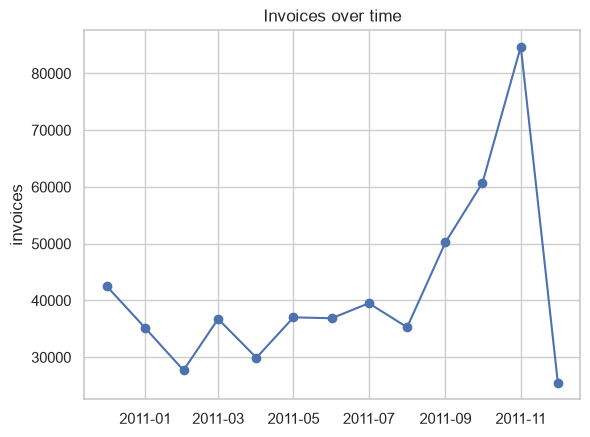

In [6]:
# Invoice volume per calendar month — checks for gaps/seasonality and confirms
# the dataset has continuous coverage over the full window.
per_month = (
    df.sort("InvoiceDate")
      .group_by_dynamic("InvoiceDate", every="1mo")   # bucket rows into monthly bins
      .agg(pl.len().alias("invoices"))                 # count rows (line items) per month
)

plt.plot(per_month["InvoiceDate"], per_month["invoices"], marker="o")
plt.ylabel("invoices")
plt.title("Invoices over time")
plt.show()

In [7]:
# Cardinality of the key dimensions — how many distinct orders, customers,
# products and countries we're dealing with.
df.select(pl.n_unique("InvoiceNo"), pl.n_unique("CustomerID"),
          pl.n_unique("StockCode"), pl.n_unique("Country"))

InvoiceNo,CustomerID,StockCode,Country
u32,u32,u32,u32
25900,4373,4070,38


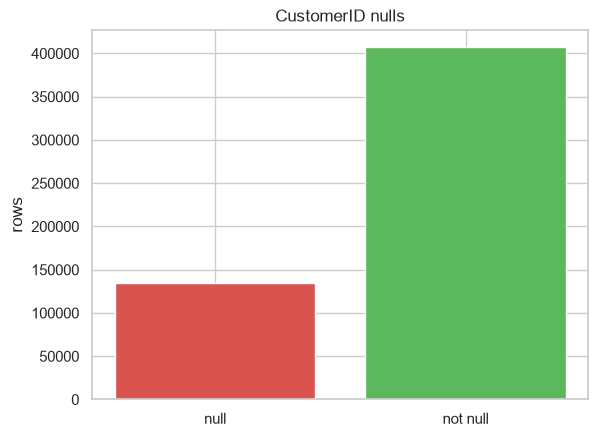

In [8]:
# Quantify the missing-customer problem: how many rows have no CustomerID and
# therefore can't be attributed to a customer for segmentation.
counts = df.select(
    pl.col("CustomerID").is_null().sum().alias("null"),
    pl.col("CustomerID").is_not_null().sum().alias("not null"),
).row(0)

plt.bar(["null", "not null"], counts, color=["#d9534f", "#5cb85c"])
plt.ylabel("rows")
plt.title("CustomerID nulls")
plt.show()

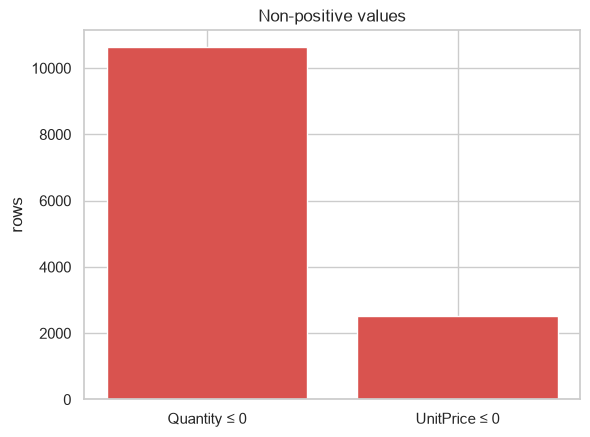

In [9]:
# Quantify non-positive values: Quantity <= 0 (returns/cancellations) and
# UnitPrice <= 0 (freebies/adjustments) — neither represents a genuine sale.
counts = df.select(
    (pl.col("Quantity") <= 0).sum().alias("Quantity ≤ 0"),
    (pl.col("UnitPrice") <= 0).sum().alias("UnitPrice ≤ 0"),
).row(0)

plt.bar(["Quantity ≤ 0", "UnitPrice ≤ 0"], counts, color="#d9534f")
plt.ylabel("rows")
plt.title("Non-positive values")
plt.show()

## 2. Data cleaning & scoping

Based on the issues found above, we clean in steps and re-inspect as we go:

1. **Drop rows with no `CustomerID`** — required for customer-level aggregation.
2. **Restrict to the United Kingdom** — it accounts for ~89% of transactions; mixing in a long tail of tiny foreign markets would add noise without enough volume to model reliably.
3. **Remove non-product line items** (postage, samples, fees, manual adjustments — `StockCode`s that aren't the usual 5-digit product codes).
4. **Remove returns and their matching original sales** (invoices starting with `C` are cancellations) so a returned order doesn't inflate a customer's apparent spend.

We start with the missing-customer filter.

In [10]:
# Step 1 of cleaning: drop rows with no CustomerID — they can't be tied to a
# customer, so they're unusable for customer-level segmentation.
df = df.filter(pl.col("CustomerID").is_not_null())

### Why restrict to the UK

The two tables and bar charts below show the country mix. The UK alone is ~89% of transactions, and even the largest "other" markets (Germany, France, EIRE) are only ~2% each. Those volumes are too thin to segment reliably and likely follow different buying patterns, so we model the UK as a single coherent population.

In [11]:
# Country mix as a share of transactions — the UK is ~89%, justifying the UK-only scope.
df['Country'].value_counts(normalize=True).sort('proportion', descending=True).head(5)

Country,proportion
str,f64
"""United Kingdom""",0.889509
"""Germany""",0.023339
"""France""",0.020871
"""EIRE""",0.018398
"""Spain""",0.006226


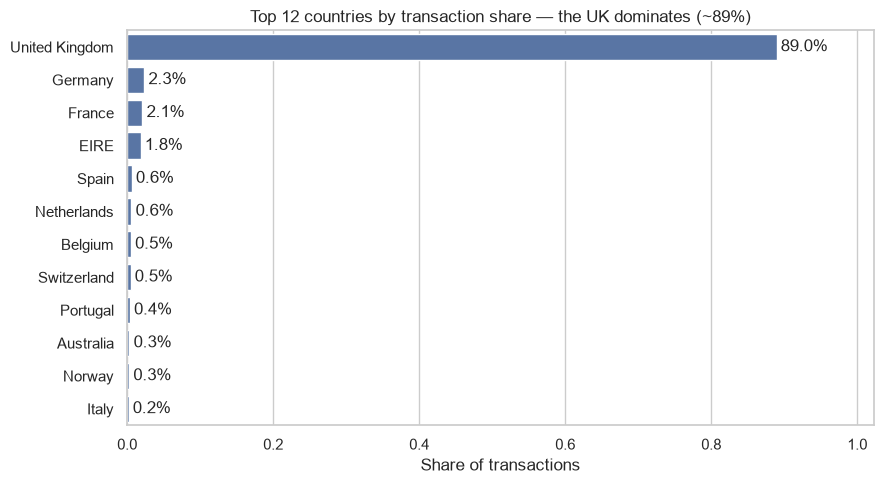

In [12]:
# Visualize why we restrict the analysis to the UK
top = (
    df["Country"].value_counts(normalize=True)
    .sort("proportion", descending=True)
    .head(12)
    .to_pandas()
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=top, y="Country", x="proportion", color=BLUE)
ax.bar_label(ax.containers[0], labels=[f"{p:.1%}" for p in top["proportion"]], padding=3)
ax.set(xlabel="Share of transactions", ylabel="",
       title="Top 12 countries by transaction share — the UK dominates (~89%)")
ax.set_xlim(0, top["proportion"].max() * 1.15)
plt.tight_layout()
plt.show()

In [13]:
# Same view with the UK excluded — shows that even the largest "other" markets
# (Germany, France, EIRE) are individually tiny, too thin to segment reliably.
df.filter(pl.col("Country") != "United Kingdom")['Country'].value_counts(normalize=True).sort('proportion', descending=True).head(5)

Country,proportion
str,f64
"""Germany""",0.21123
"""France""",0.188895
"""EIRE""",0.166515
"""Spain""",0.05635
"""Netherlands""",0.052746


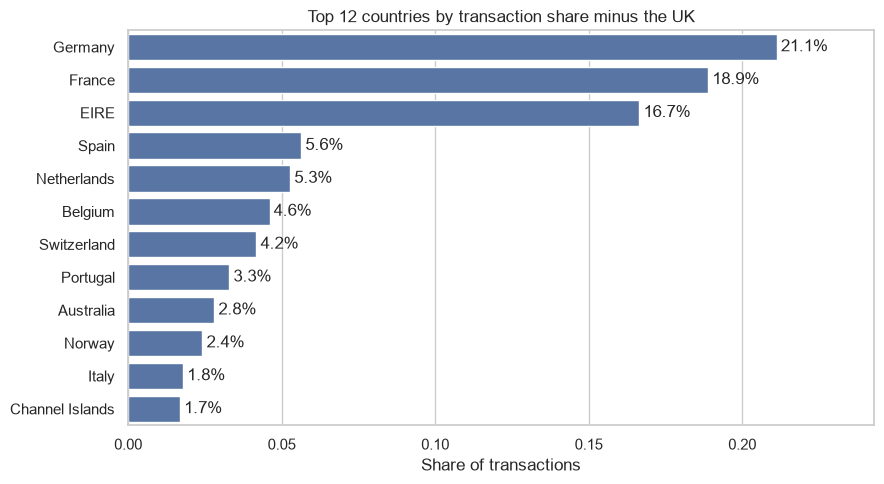

In [14]:
# Visualize why we restrict the analysis to the UK
top = (
    df.filter(pl.col("Country") != "United Kingdom")["Country"].value_counts(normalize=True)
    .sort("proportion", descending=True)
    .head(12)
    .to_pandas()
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=top, y="Country", x="proportion", color=BLUE)
ax.bar_label(ax.containers[0], labels=[f"{p:.1%}" for p in top["proportion"]], padding=3)
ax.set(xlabel="Share of transactions", ylabel="",
       title="Top 12 countries by transaction share minus the UK")
ax.set_xlim(0, top["proportion"].max() * 1.15)
plt.tight_layout()
plt.show()

In [15]:
# Step 2 of cleaning: keep only UK rows and drop the now-constant Country column.
df_uk = df.filter(pl.col("Country") == "United Kingdom").drop("Country")

In [16]:
# Re-inspect after the UK filter — negative Quantity and non-product codes
# (e.g. "POST") are still present, handled in the next steps.
df_uk.describe()

statistic,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
str,str,str,str,f64,str,f64,f64
"""count""","""361878""","""361878""","""361878""",361878.0,"""361878""",361878.0,361878.0
"""null_count""","""0""","""0""","""0""",0.0,"""0""",0.0,0.0
"""mean""",null,null,null,11.077029,"""2011-07-10 23:48:12.301000""",3.256007,15547.871368
"""std""",null,null,null,263.129266,null,70.654731,1594.40259
"""min""","""536365""","""10002""",""" 4 PURPLE FLOCK DINNER CANDLES""",-80995.0,"""2010-12-01 08:26:00""",0.0,12346.0
"""25%""",null,null,null,2.0,"""2011-04-06 17:25:00""",1.25,14194.0
"""50%""",null,null,null,4.0,"""2011-07-31 13:07:00""",1.95,15514.0
"""75%""",null,null,null,12.0,"""2011-10-23 11:39:00""",3.75,16931.0
"""max""","""C581569""","""POST""","""ZINC WIRE SWEETHEART LETTER TR…",80995.0,"""2011-12-09 12:49:00""",38970.0,18287.0


### Remove non-product items, returns & cancellations

The UK subset still contains negative quantities (returns) and `StockCode`s that aren't real products (postage `POST`, samples, discounts `D`, manual adjustments). We:

- inspect the offending rows,
- drop non-5-digit product codes,
- and drop cancellation invoices (`C…`) together with the original sale they reverse, matched on customer + product + quantity + price.

Finally we add a `total_amount = Quantity × UnitPrice` line-revenue column and confirm the cleaned table looks sane.

In [17]:
# Inspect the non-positive-quantity rows: these are cancellations ("C..." invoices),
# discounts ("D") and other adjustments rather than real product sales.
df_uk.filter(pl.col("Quantity") <= 0).head(5)

InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
str,str,str,i64,datetime[ms],f64,i64
"""C536379""","""D""","""Discount""",-1,2010-12-01 09:41:00,27.5,14527
"""C536383""","""35004C""","""SET OF 3 COLOURED FLYING DUCK…",-1,2010-12-01 09:49:00,4.65,15311
"""C536391""","""22556""","""PLASTERS IN TIN CIRCUS PARADE """,-12,2010-12-01 10:24:00,1.65,17548
"""C536391""","""21984""","""PACK OF 12 PINK PAISLEY TISSUE…",-24,2010-12-01 10:24:00,0.29,17548
"""C536391""","""21983""","""PACK OF 12 BLUE PAISLEY TISSUE…",-24,2010-12-01 10:24:00,0.29,17548


In [18]:
# Identify non-product line items: real products use 5-digit StockCodes, so any
# code NOT starting with 5 digits (POST, D, M, BANK CHARGES, ...) is excluded.
# Listed by frequency so we can eyeball what's being removed.
non_product = (df_uk
    .filter(~pl.col("StockCode").str.contains(r"^\d{5}"))   # ~ negates: keep the non-5-digit codes
    .group_by("StockCode")
    .agg(pl.len().alias("rows"))
    .sort("rows", descending=True))

In [19]:
# Step 3 of cleaning: drop those non-product line items from the UK data.
df_uk = df_uk.filter(~pl.col("StockCode").is_in(non_product["StockCode"].to_list()))

In [20]:
# Step 4 of cleaning: remove returns and the original sales they reverse.
# Cancellation invoices start with "C". For each cancelled line we build the key
# of the positive sale it offsets (same customer/product/price, quantity sign flipped)...
key_cols = ["CustomerID", "StockCode", "Quantity", "UnitPrice"]
cancellations = df.filter(pl.col("InvoiceNo").str.starts_with("C"))
cancel_keys = cancellations.select(
    "CustomerID",
    "StockCode",
    (-pl.col("Quantity")).alias("Quantity"),   # flip sign so it matches the original purchase
    "UnitPrice",
).unique()
# ...then drop the cancellation rows themselves AND anti-join out their matching
# original sales, so a returned order doesn't inflate the customer's apparent spend.
df_uk = (
    df_uk
    .filter(~pl.col("InvoiceNo").str.starts_with("C"))
    .join(cancel_keys, on=key_cols, how="anti")
)

In [21]:
# Drop the free-text Description (not needed downstream) and add per-line revenue.
df_uk = df_uk.drop('Description').with_columns(
    total_amount=pl.col("Quantity") * pl.col("UnitPrice")   # line revenue = qty × price
)

In [22]:
# Confirm the cleaned table is sane: Quantity/UnitPrice now strictly positive
# and total_amount is populated.
df_uk.describe()

statistic,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,total_amount
str,str,str,f64,str,f64,f64,f64
"""count""","""349782""","""349782""",349782.0,"""349782""",349782.0,349782.0,349782.0
"""null_count""","""0""","""0""",0.0,"""0""",0.0,0.0,0.0
"""mean""",null,null,11.469292,"""2011-07-11 14:08:54.422000""",2.832024,15550.139238,19.524698
"""std""",null,null,45.691256,null,4.159618,1593.999996,92.874771
"""min""","""536365""","""10002""",1.0,"""2010-12-01 08:26:00""",0.0,12747.0,0.0
"""25%""",null,null,2.0,"""2011-04-07 12:16:00""",1.25,14194.0,4.16
"""50%""",null,null,4.0,"""2011-08-01 12:48:00""",1.85,15522.0,10.2
"""75%""",null,null,12.0,"""2011-10-23 15:11:00""",3.75,16931.0,17.7
"""max""","""581586""","""90214Z""",12540.0,"""2011-12-09 12:49:00""",649.5,18287.0,38970.0


In [23]:
# Check for duplicate rows — there shouldn't be any, but if there are we drop them to avoid double-counting.
df_uk.is_duplicated().sum()

9697

In [24]:
# Remove duplicate rows
df_uk = df_uk.unique()

In [25]:
# Make sure the duplicates are gone
df_uk.is_duplicated().sum()

0

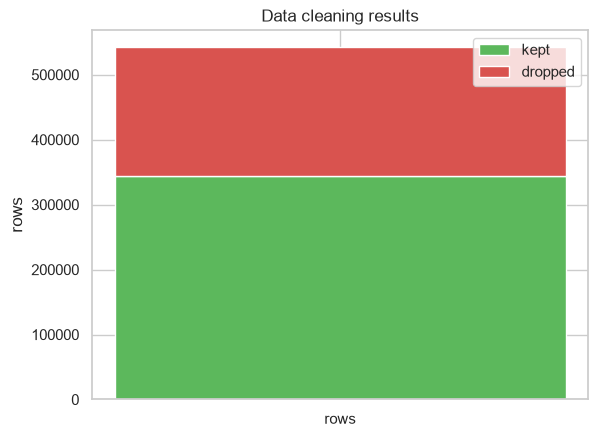

In [29]:
# Visualize the overall impact of cleaning: how many of the original rows were
# kept vs. dropped across all four cleaning steps.
final_rows = df_uk.height

dropped = raw_rows - final_rows

plt.bar(["rows"], [final_rows], label="kept", color="#5cb85c")
plt.bar(["rows"], [dropped], bottom=[final_rows], label="dropped", color="#d9534f")   # stacked on top
plt.ylabel("rows")
plt.title("Data cleaning results")
plt.legend()
plt.show()

### Post-cleaning sanity checks

With the data cleaned, we re-examine it to confirm it behaves as expected before modeling: monthly revenue/order volume, and the transaction-level distributions of `Quantity`, `UnitPrice` and `total_amount`. The log y-axis exposes the heavy right tails — a few huge orders alongside many small ones — which is why the customer features will need a log transform later.

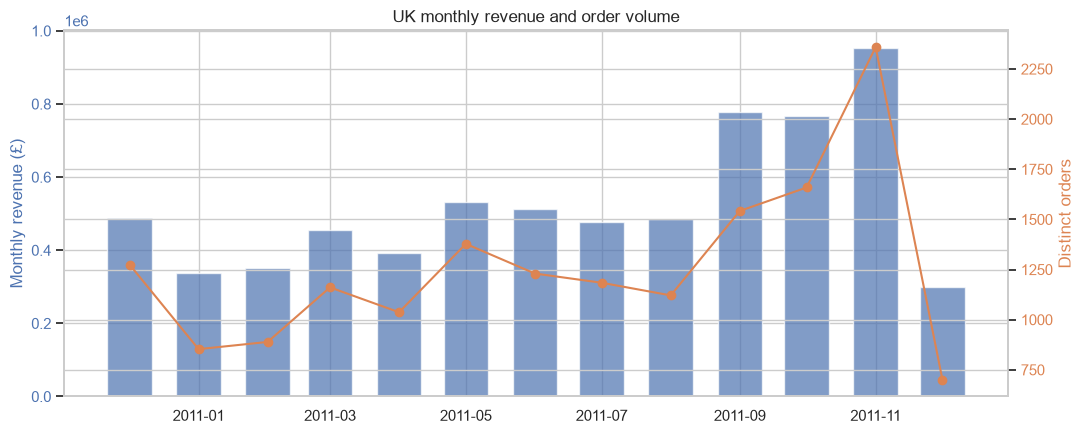

In [24]:
# Monthly revenue and order volume (seasonality / data coverage)
monthly = (
    df_uk.sort("InvoiceDate")
    .group_by_dynamic("InvoiceDate", every="1mo")
    .agg(
        pl.col("total_amount").sum().alias("revenue"),
        pl.col("InvoiceNo").n_unique().alias("orders"),
    )
    .sort("InvoiceDate")
    .to_pandas()
)

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.bar(monthly["InvoiceDate"], monthly["revenue"], width=20, color=BLUE, alpha=0.7)
ax1.set_ylabel("Monthly revenue (£)", color=BLUE)
ax1.tick_params(axis="y", labelcolor=BLUE)
ax2 = ax1.twinx()
ax2.plot(monthly["InvoiceDate"], monthly["orders"], color=ORANGE, marker="o")
ax2.set_ylabel("Distinct orders", color=ORANGE)
ax2.tick_params(axis="y", labelcolor=ORANGE)
ax1.set_title("UK monthly revenue and order volume")
plt.tight_layout()
plt.show()

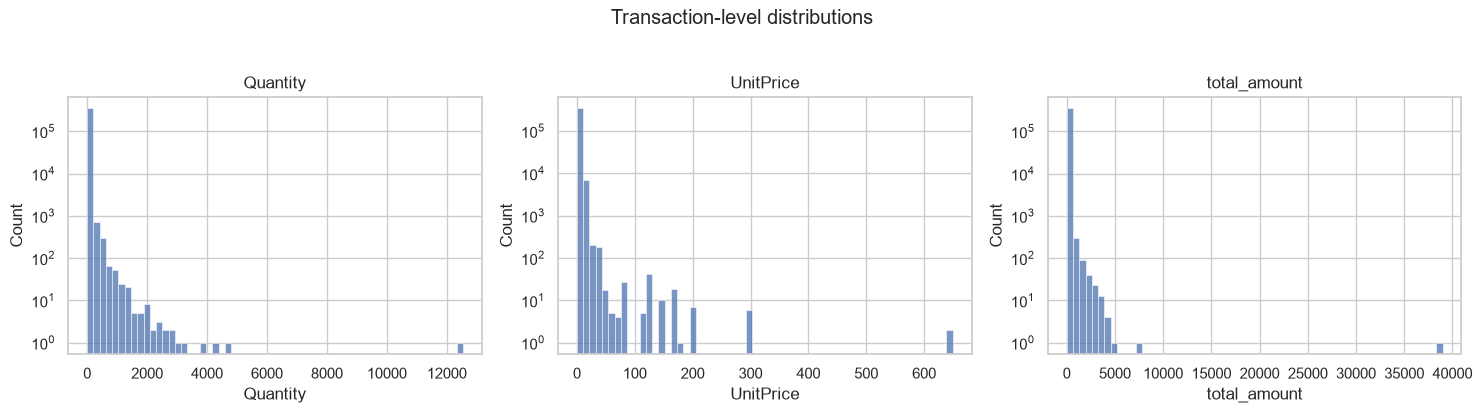

In [25]:
# Transaction-level distributions (log y-axis exposes the long right tails)
cols = ["Quantity", "UnitPrice", "total_amount"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, cols):
    sns.histplot(df_uk[col].to_numpy(), bins=60, ax=ax, color=BLUE)
    ax.set_yscale("log")
    ax.set_title(col)
    ax.set_xlabel(col)
fig.suptitle("Transaction-level distributions", y=1.03)
plt.tight_layout()
plt.show()

## 3. Customer-level feature engineering (RFM-style)

Clustering operates on **customers**, not transactions, so we aggregate the cleaned line items to one row per `CustomerID`. The six features capture the classic **RFM** dimensions plus engagement:

| Feature | Captures |
|---|---|
| `num_orders` | **F**requency — distinct invoices |
| `num_products` | breadth of catalogue purchased |
| `total_spent` | **M**onetary — lifetime revenue |
| `avg_order_value` | typical basket size |
| `tenure_days` | how long they've been active (first → last order) |
| `recency_days` | **R**ecency — days since last order vs. the snapshot date |

The snapshot (`ref_date`) is the most recent activity in the dataset, so recency is measured relative to "now" in the data's frame of reference.

In [26]:
# Collapse the cleaned line items to one row per customer, computing the raw
# building blocks for the RFM-style features.
customers = df_uk.group_by("CustomerID").agg(
    pl.col("InvoiceNo").n_unique().alias("num_orders"),      # F: distinct orders
    pl.col("StockCode").n_unique().alias("num_products"),    # breadth of catalogue bought
    pl.col("total_amount").sum().alias("total_spent"),       # M: lifetime revenue
    pl.col("InvoiceDate").min().alias("first_order"),        # used for tenure
    pl.col("InvoiceDate").max().alias("last_order"),         # used for tenure & recency
    (pl.col("InvoiceDate").max() - pl.col("InvoiceDate").min()).alias("tenure"),
).sort("total_spent", descending=True)

In [27]:
# Snapshot date = most recent activity in the dataset.
ref_date = customers["last_order"].max()

In [28]:
# The six features fed to the model (order matters: used later to index the skewed columns).
feature_cols = [
    "num_orders",
    "num_products",
    "total_spent",
    "avg_order_value",
    "tenure_days",
    "recency_days",
]

# Derive the final numeric features from the per-customer aggregates:
features = customers.with_columns(
    tenure_days=pl.col("tenure").dt.total_days(),                          # active span in days
    recency_days=(pl.lit(ref_date) - pl.col("last_order")).dt.total_days(),# R: days since last order
    avg_order_value=pl.col("total_spent") / pl.col("num_orders"),         # typical basket size
)

### Customer-level feature distributions

These are the six features fed to the model. The monetary and count features (`num_orders`, `num_products`, `total_spent`, `avg_order_value`) are strongly right-skewed — a handful of whales dwarf everyone else — which is exactly why they get a `log1p` transform before scaling. Recency and tenure are roughly bounded by the ~1-year window, so they're left linear.

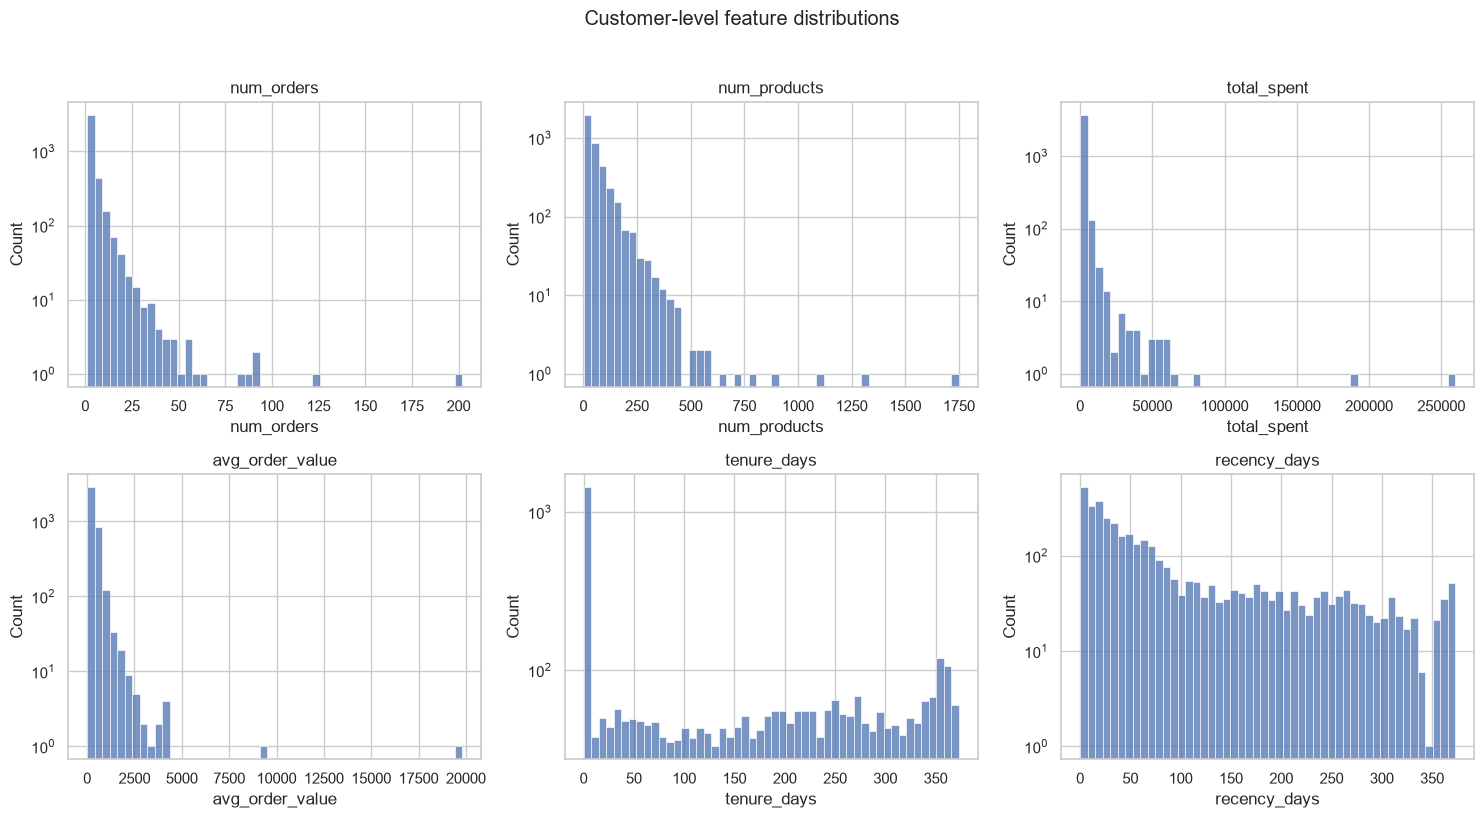

In [29]:
# Distribution of every clustering feature on the customer level.
# Log y-axis makes the heavy right skew of the count/money features visible —
# motivating the log1p transform applied in the next section.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), feature_cols):
    sns.histplot(features[col].to_numpy(), bins=50, ax=ax, color=BLUE)
    ax.set_yscale("log")
    ax.set_title(col)
    ax.set_xlabel(col)
fig.suptitle("Customer-level feature distributions", y=1.02)
plt.tight_layout()
plt.show()

## 4. Preprocessing — transform & scale

Two steps prepare the features for a distance-based algorithm:

- **`log1p` the skewed columns** so a few extreme spenders don't dominate the distance metric (`log1p` handles zeros safely).
- **`StandardScaler`** so every feature contributes on a comparable scale — without this, `total_spent` (thousands) would swamp `num_orders` (single digits) in the Euclidean distance K-Means uses.

In [30]:
# Build the model matrix (rows = customers, cols = the 6 features) as floats.
X = features.select(feature_cols).to_numpy().astype(float)

# Log-transform the heavily right-skewed columns (counts + money) in place so a
# few extreme spenders don't dominate the Euclidean distance. log1p handles zeros
# safely; recency/tenure are roughly bounded by the 1-year window so left linear.
skewed = ["num_orders", "num_products", "total_spent", "avg_order_value"]
skewed_idx = [feature_cols.index(c) for c in skewed]   # column positions in X
X[:, skewed_idx] = np.log1p(X[:, skewed_idx])

# Standardize every feature to mean 0 / unit variance so each contributes
# comparably — otherwise total_spent (thousands) would swamp num_orders (single digits).
X_scaled = StandardScaler().fit_transform(X)

## 5. Choosing the number of clusters *k*

K-Means needs *k* specified up front, so we sweep `k = 2…10` and judge each with four diagnostics rather than trusting any single one:

- **Inertia (elbow)** — within-cluster spread; look for the bend where extra clusters stop helping.
- **Silhouette** *(higher better)* — separation vs. cohesion per point.
- **Davies–Bouldin** *(lower better)* — average overlap between clusters.
- **Calinski–Harabasz** *(higher better)* — ratio of between- to within-cluster variance.

Using three internal metrics lets us cross-check the value of k

In [31]:
# Sweep k = 2..10, fitting K-Means at each and recording four diagnostics so we
# can cross-check rather than trust any single metric.
ks = list(range(2, 11))
inertias, silhouettes, davies_bouldins, calinski_harabaszs = [], [], [], []
print(f"{'k':>3} {'inertia':>12} {'silhouette':>12} {'davies_bould':>14} {'calinski_har':>14}")
for k in ks:
    # n_init=10: restart 10 times with different seeds and keep the best (guards
    # against bad random initialization); random_state fixes reproducibility.
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    dbi = davies_bouldin_score(X_scaled, labels)
    chi = calinski_harabasz_score(X_scaled, labels)
    inertias.append(km.inertia_)            # within-cluster sum of squares (for the elbow)
    silhouettes.append(sil)
    davies_bouldins.append(dbi)
    calinski_harabaszs.append(chi)
    print(f"{k:>3} {km.inertia_:>12.1f} {sil:>12.3f} {dbi:>14.3f} {chi:>14.1f}")

  k      inertia   silhouette   davies_bould   calinski_har
  2      13628.3        0.357          1.074         2814.5
  3      11096.7        0.263          1.331         2173.3
  4       9612.8        0.252          1.273         1873.0
  5       8291.4        0.244          1.261         1783.7
  6       7516.8        0.245          1.230         1654.0
  7       6911.9        0.230          1.215         1555.5
  8       6460.8        0.227          1.224         1464.9
  9       6111.6        0.214          1.260         1382.5
 10       5803.9        0.220          1.305         1316.7


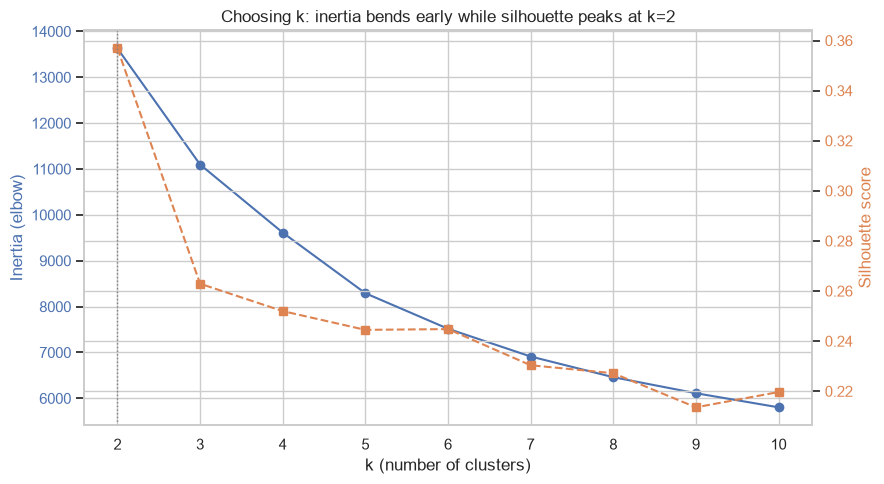

In [32]:
# Elbow (inertia) + silhouette vs k on one figure
best_k = ks[int(np.argmax(silhouettes))]
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(ks, inertias, "o-", color=BLUE)
ax1.set_xlabel("k (number of clusters)")
ax1.set_ylabel("Inertia (elbow)", color=BLUE)
ax1.tick_params(axis="y", labelcolor=BLUE)
ax2 = ax1.twinx()
ax2.plot(ks, silhouettes, "s--", color=ORANGE)
ax2.set_ylabel("Silhouette score", color=ORANGE)
ax2.tick_params(axis="y", labelcolor=ORANGE)
ax2.axvline(best_k, color="grey", ls=":", lw=1)
ax1.set_title(f"Choosing k: inertia bends early while silhouette peaks at k={best_k}")
plt.tight_layout()
plt.show()

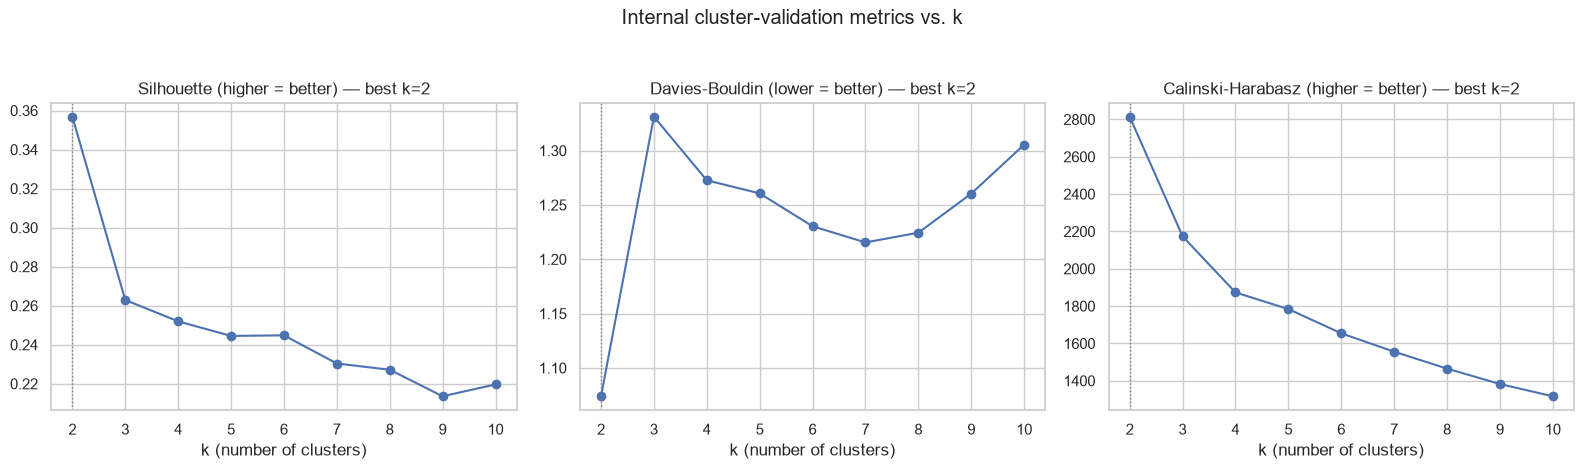

In [33]:
# Cross-check k with three internal metrics side by side.
# Here all three agree: silhouette (max), Davies-Bouldin (min) and
# Calinski-Harabasz (max) all point to k=2 — a reassuringly consistent
# signal that the cleanest structure in the data is a two-way split.
best_sil_k = ks[int(np.argmax(silhouettes))]
best_dbi_k = ks[int(np.argmin(davies_bouldins))]
best_chi_k = ks[int(np.argmax(calinski_harabaszs))]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, vals, title, best, better in [
    (axes[0], silhouettes, "Silhouette", best_sil_k, "higher = better"),
    (axes[1], davies_bouldins, "Davies-Bouldin", best_dbi_k, "lower = better"),
    (axes[2], calinski_harabaszs, "Calinski-Harabasz", best_chi_k, "higher = better"),
]:
    ax.plot(ks, vals, "o-", color=BLUE)
    ax.axvline(best, color="grey", ls=":", lw=1)
    ax.set_xlabel("k (number of clusters)")
    ax.set_title(f"{title} ({better}) — best k={best}")
fig.suptitle("Internal cluster-validation metrics vs. k", y=1.04)
plt.tight_layout()
plt.show()

## 6. Fit the final model & validate

**Decision:** all three internal metrics agree on **k = 2** — silhouette is highest (0.357), Davies–Bouldin is lowest (1.074) and Calinski–Harabasz is highest (2814.5), all at k = 2. That unanimous signal makes k = 2 the clear, defensible choice, so we fit the final model there. The per-sample silhouette plot below then shows how tightly each individual customer sits within its assigned cluster.

> The metrics favour a clean two-way split. If marketing later needed finer personas, k = 3–4 would be the next thing to explore — but it would trade measurable cohesion for granularity.

In [34]:
# Fit the final model at k=2 (chosen above) and attach each customer's cluster
# label back onto the feature table for profiling.
k = 2
km = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)

result = features.with_columns(cluster=pl.Series(labels))

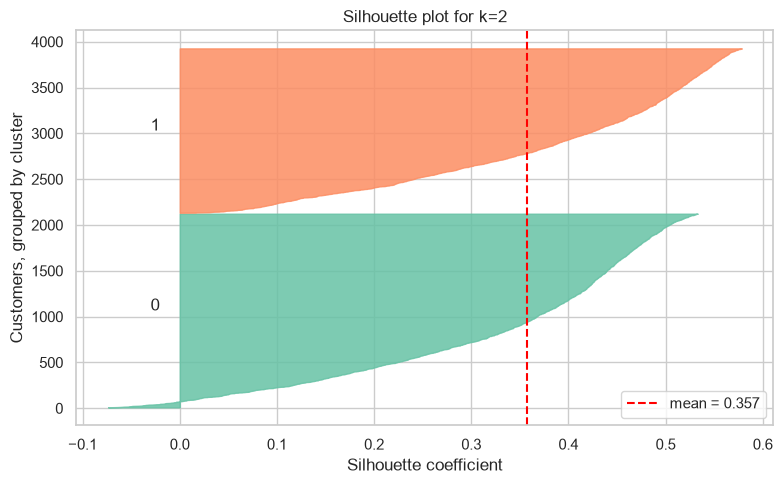

In [35]:
# Per-sample silhouette plot for the chosen k — shows separation quality per cluster
sample_sil = silhouette_samples(X_scaled, labels)   # silhouette coefficient for every customer
overall = sample_sil.mean()                          # = the overall silhouette_score

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10                                          # running y-offset, with a gap between clusters
palette = sns.color_palette("Set2", k)
for i in range(k):
    vals = np.sort(sample_sil[labels == i])          # this cluster's coefficients, sorted -> "knife" shape
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, color=palette[i], alpha=0.85)
    ax.text(-0.03, y_lower + 0.5 * len(vals), str(i))  # label the cluster
    y_lower = y_upper + 10                            # leave a gap before the next cluster
ax.axvline(overall, color="red", ls="--", label=f"mean = {overall:.3f}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Customers, grouped by cluster")
ax.set_title(f"Silhouette plot for k={k}")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Profile & interpret the segments

A cluster is only useful if we can describe it in business terms. We summarize each cluster on the **original (un-logged) scale** so the averages are readable, then visualize how every feature splits across clusters. The two segments that emerge:

- **Cluster 0 — one-off / low-engagement buyers:** ~1–2 orders, low total spend, long since their last purchase, short tenure.
- **Cluster 1 — loyal high-value customers:** many orders, large lifetime spend, recently active, long tenure.

This is a textbook "core vs. casual" split that maps directly onto retention vs. acquisition strategies.

In [36]:
# Summarize each cluster on the original (un-logged) scale so the averages are
# directly readable in business terms.
profile = (
    result.group_by("cluster")
    .agg(
        pl.len().alias("n_customers"),
        pl.col("num_orders").mean().round(1).alias("avg_orders"),
        pl.col("total_spent").mean().round(0).alias("avg_spent"),
        pl.col("avg_order_value").mean().round(1).alias("avg_basket"),
        pl.col("recency_days").mean().round(0).alias("avg_recency_d"),
        pl.col("tenure_days").mean().round(0).alias("avg_tenure_d"),
    )
    .sort("cluster")
)

profile

cluster,n_customers,avg_orders,avg_spent,avg_basket,avg_recency_d,avg_tenure_d
i32,u32,f64,f64,f64,f64,f64
0,2114,1.5,388.0,283.4,139.0,34.0
1,1794,7.4,3350.0,428.9,36.0,244.0


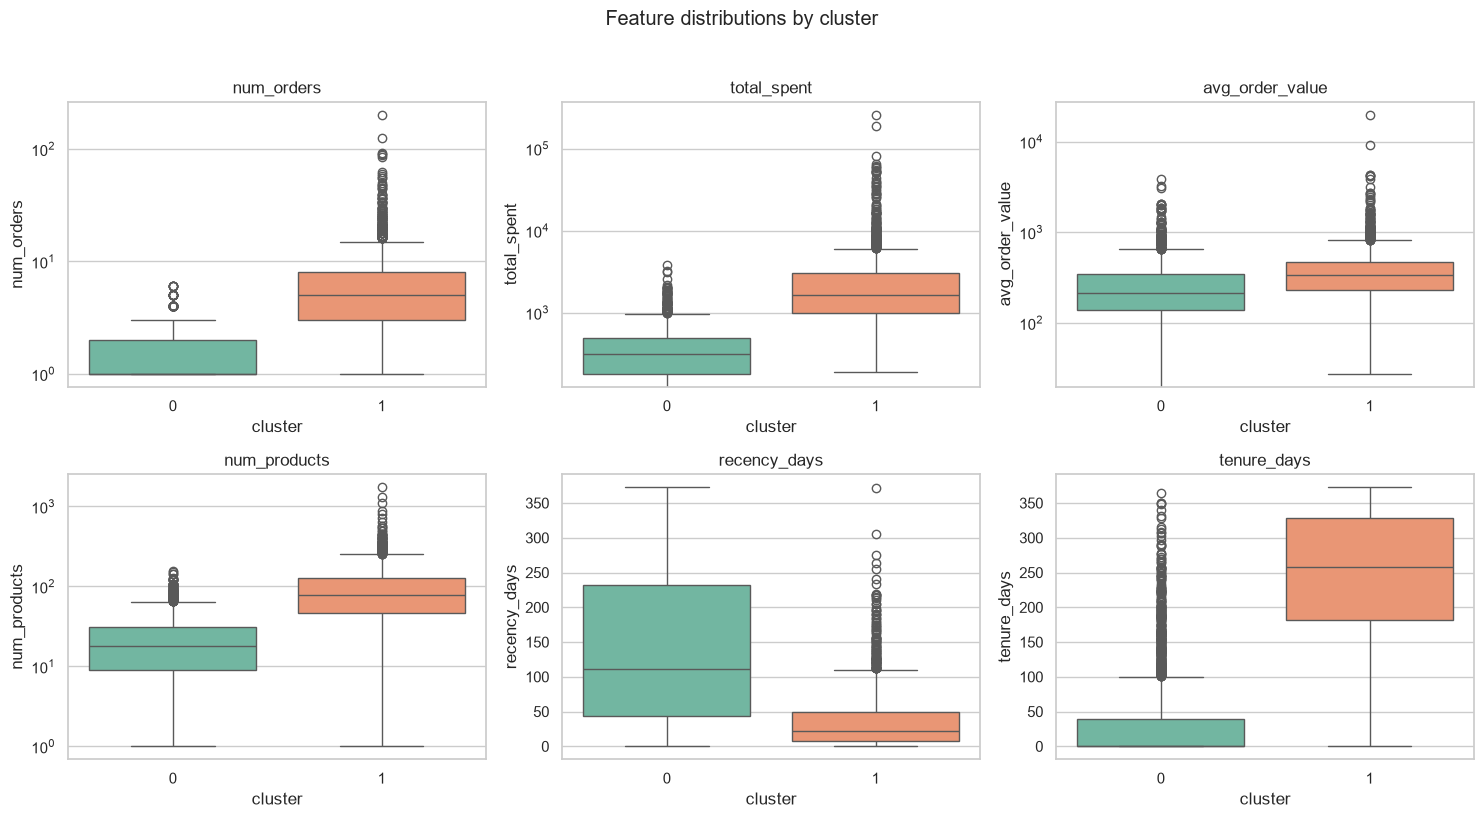

In [37]:
# How each original-scale feature splits across clusters
plot_cols = ["num_orders", "total_spent", "avg_order_value",
             "num_products", "recency_days", "tenure_days"]
log_cols = {"num_orders", "total_spent", "avg_order_value", "num_products"}  # log-scaled axes (skewed)
pdf = result.select(plot_cols + ["cluster"]).to_pandas()                     # seaborn needs pandas
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), plot_cols):
    sns.boxplot(data=pdf, x="cluster", y=col, hue="cluster",
                legend=False, palette="Set2", ax=ax)
    if col in log_cols:
        ax.set_yscale("log")     # log axis keeps the skewed features readable
    ax.set_title(col)
fig.suptitle("Feature distributions by cluster", y=1.02)
plt.tight_layout()
plt.show()

### Visualizing the segments in 2D (PCA)

The clustering happens in 6-dimensional feature space, which we can't see directly. PCA projects it down to the two directions of greatest variance so we can eyeball cluster separation. The interactive scatter (hover for `CustomerID`, spend, orders) and the % of variance each component captures tell us how much of the real structure this 2D view preserves.

In [38]:
import pandas as pd
import plotly.express as px

# Project the 6 scaled features down to 2 principal components.
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
ev = pca.explained_variance_ratio_

plot_df = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "cluster": labels.astype(str),
    "CustomerID": result["CustomerID"].to_numpy(),
    "total_spent": result["total_spent"].to_numpy(),
    "num_orders": result["num_orders"].to_numpy(),
})

fig = px.scatter(
    plot_df,
    x="PC1",
    y="PC2",
    color="cluster",
    hover_data=["CustomerID", "total_spent", "num_orders"],
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Set2,
    labels={
        "PC1": f"PC1 ({ev[0]:.1%} variance)",
        "PC2": f"PC2 ({ev[1]:.1%} variance)",
    },
    title=f"Customer segments in PCA space ({ev.sum():.1%} of variance explained)",
)

fig.update_traces(marker=dict(size=6, line=dict(width=0.3, color="white")))
fig.update_layout(template="plotly_white", legend_title_text="Cluster", width=800, height=600)
fig.show()

## 8. Conclusion

**What we did:** cleaned ~542k raw transactions down to a reliable UK product-sales set, aggregated to ~3,900 customers with six RFM-style features, and segmented them with K-Means.

**Result — two clear segments:**

| Segment | Size | Behaviour | Action |
|---|---|---|---|
| **Loyal high-value** | ~1,800 | ~7 orders, ~£3,350 lifetime spend, recently active, long tenure | retain & reward (loyalty, early access) |
| **One-off / lapsed** | ~2,100 | ~1–2 orders, ~£390 spend, long since last purchase | reactivate (win-back offers) |

**Quality:** the split is unanimously validated — silhouette, Davies–Bouldin and Calinski–Harabasz all select k = 2 — and the two groups are visually separable in PCA space.

**Limitations & next steps:**
- k = 2 is the *statistically* cleanest split; a k = 3–4 model could give marketing finer-grained personas at the cost of some cohesion.
- K-Means assumes roughly spherical, similarly-sized clusters — worth sanity-checking against a density-based (DBSCAN) or hierarchical method.
- The dataset is a single ~1-year window; recency/tenure would behave differently on a longer or rolling horizon.
- Due to time constraints, this exercise was only done on UK customers. Given more time I would have created a similar exercise for customers from other countries.